# Future User Spending Prediction Using Lasso Regression

## Imports
The following libraries are used for:
- Data manipulation and analysis
- Data visualization
- Machine learning model training and evaluation

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Loading

The dataset is loaded from a CSV file into a pandas DataFrame.

A copy of the original dataset is created in order to preserve the raw data before performing preprocessing and analysis operations.

In [3]:
df = pd.read_csv("/Users/alon1/PycharmProjects/ai-shopping-project/backend/ml/user_spending_dataset.csv")
df_copy = df.copy()
df_copy

,user_id,favorite_count,closed_orders_count,total_items_purchased,average_order_value,days_since_registration,future_spending
0,1,11,2,28,158,306,893.8
1,2,2,9,15,107,194,1034.7
2,3,1,9,10,176,214,1023.0
3,4,7,3,2,94,61,472.0
4,5,11,10,9,85,82,1019.9
...,...,...,...,...,...,...,...
995,996,6,5,18,109,78,821.9
996,997,7,5,23,168,61,982.8
997,998,6,10,31,143,37,1331.5
998,999,11,10,28,95,124,1287.3


## Data Preparation

### Removing Non-Informative Columns

Before training the model, non-informative columns that do not contribute to the prediction task were removed from the dataset.

#### user_id
The `user_id` column represents a unique identifier and does not contain meaningful predictive information regarding future user spending.

Removing this column helps the model focus only on relevant behavioral features.

In [4]:
df_copy = df_copy.drop(columns=["user_id"])
df_copy.head()

,favorite_count,closed_orders_count,total_items_purchased,average_order_value,days_since_registration,future_spending
0,11,2,28,158,306,893.8
1,2,9,15,107,194,1034.7
2,1,9,10,176,214,1023.0
3,7,3,2,94,61,472.0
4,11,10,9,85,82,1019.9


### Missing Values Check

The following analysis checks whether the dataset contains missing values.

For each feature, the table presents:
- Total number of rows
- Number of missing values
- Percentage of missing values

This step is important to ensure the dataset is clean before training the machine learning model.

In [5]:
missing_data = df_copy.isnull().sum()

total_values = df_copy.count()

percentage_missing = (missing_data / len(df_copy)) * 100

final_missing_data = pd.concat(
    [total_values, missing_data, percentage_missing],
    axis=1,
    keys=["Total Values", "Missing Values", "Missing Percentage"]
)

final_missing_data

,Total Values,Missing Values,Missing Percentage
favorite_count,1000,0,0.0
closed_orders_count,1000,0,0.0
total_items_purchased,1000,0,0.0
average_order_value,1000,0,0.0
days_since_registration,1000,0,0.0
future_spending,1000,0,0.0


### Duplicate Rows Check

The dataset was checked for duplicate rows using the `duplicated()` function.

Duplicate samples may negatively affect the model training process and bias the learning patterns, therefore verifying dataset uniqueness is an important preprocessing step.

In [6]:
num_duplicates = df_copy.duplicated().sum()
print("Number of duplicate rows:", num_duplicates)

Number of duplicate rows: 0


## Data Exploration

### Pairwise Relationships Visualization

A pairplot visualization was generated in order to explore the relationships between the numerical features in the dataset.

This visualization helps identify:
- Linear relationships between variables
- Potential feature correlations
- Data distributions
- Possible outliers

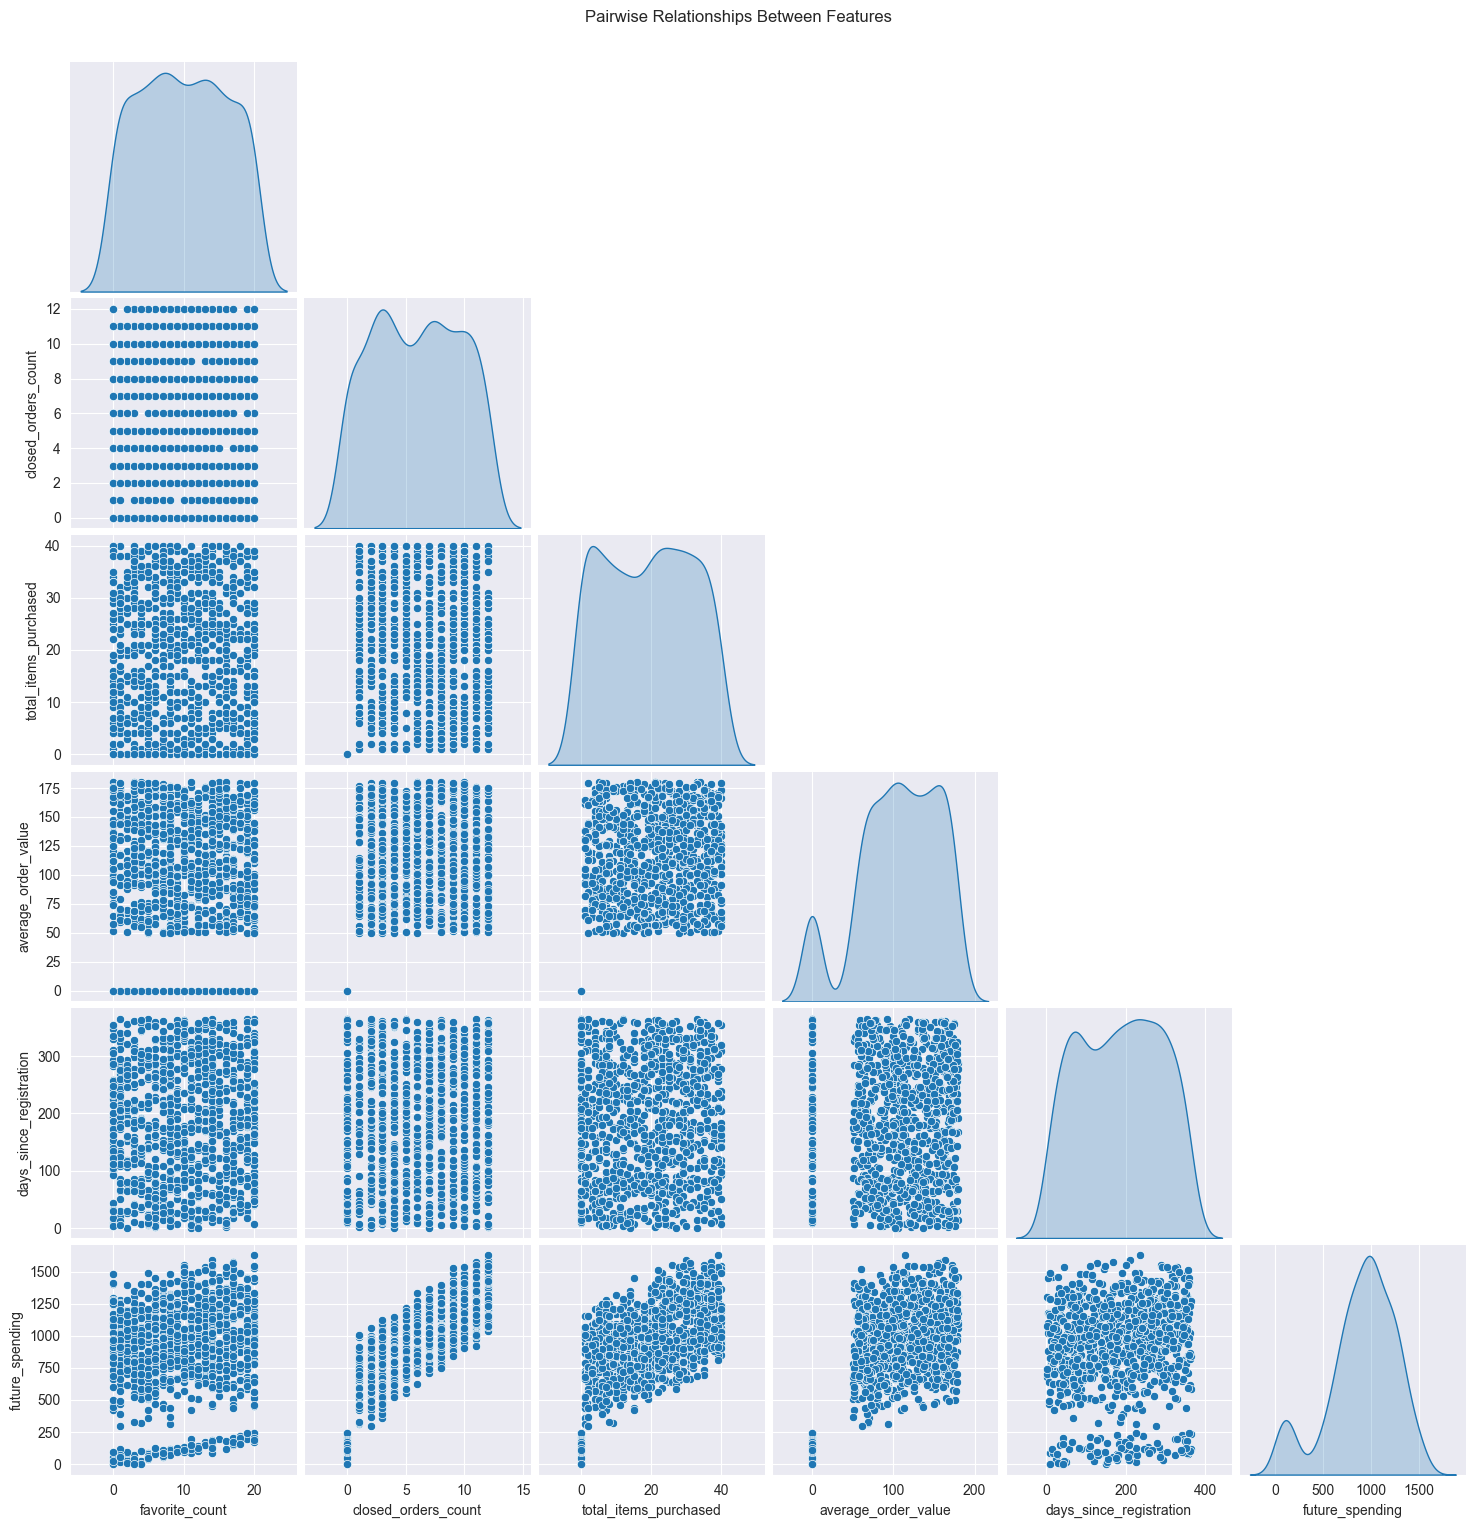

In [7]:
sns.pairplot(df_copy, diag_kind="kde", corner=True)
plt.suptitle("Pairwise Relationships Between Features", y=1.02)
plt.show()

### Correlation Matrix Calculation

The correlation matrix is computed in order to measure the linear relationship between each feature and `future_spending`, as well as between the features themselves.

This analysis helps identify:
- Strong predictive relationships
- Potential multicollinearity between features
- Features that may have a significant impact on the target variable

In [8]:
corr_matrix = df_copy.corr()
corr_matrix

,favorite_count,closed_orders_count,total_items_purchased,average_order_value,days_since_registration,future_spending
favorite_count,1.000000,0.015701,0.008228,-0.059167,0.008111,0.144317
closed_orders_count,0.015701,1.000000,0.174047,0.299092,0.000656,0.829816
total_items_purchased,0.008228,0.174047,1.000000,0.339937,0.056038,0.630690
average_order_value,-0.059167,0.299092,0.339937,1.000000,-0.012669,0.573413
days_since_registration,0.008111,0.000656,0.056038,-0.012669,1.000000,0.078610
future_spending,0.144317,0.829816,0.630690,0.573413,0.078610,1.000000


### Correlation Heatmap Visualization

A heatmap visualization was generated from the correlation matrix in order to highlight the strength and direction of the relationships between the features and `future_spending`.

The `coolwarm` color map is used to visually distinguish:
- Strong positive correlations
- Strong negative correlations
- Weak or near-zero correlations

Additionally, correlation values are displayed directly inside the heatmap cells to improve readability and interpretation.

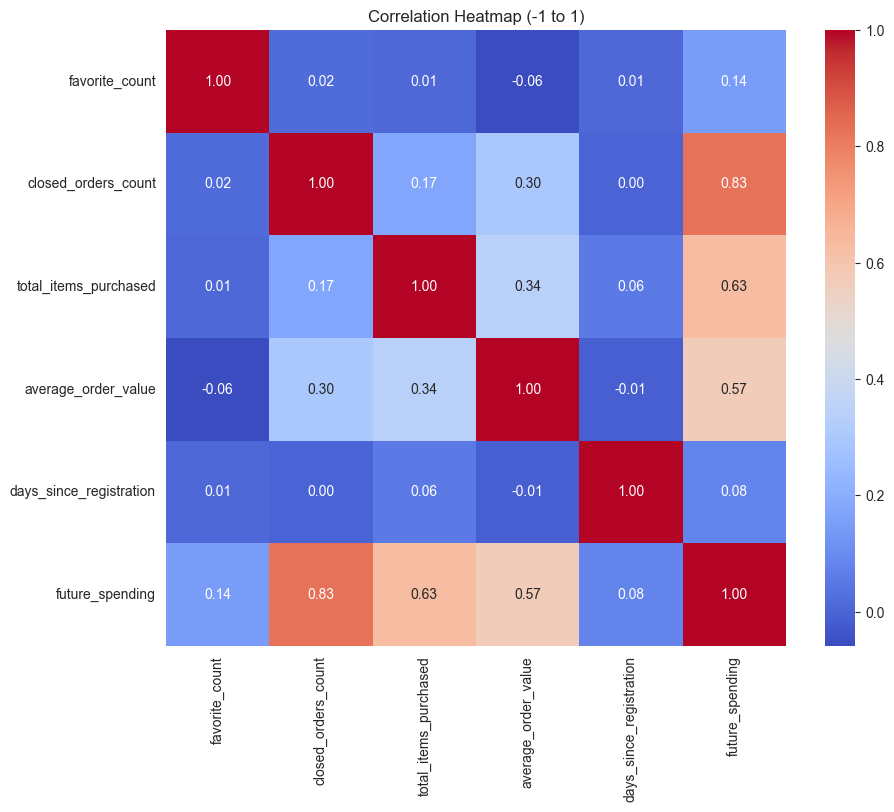

In [9]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap (-1 to 1)")

plt.show()

## Correlation Analysis - Insights

Several meaningful relationships can be observed from the correlation heatmap:

- `closed_orders_count` shows the strongest positive correlation with `future_spending` (0.83), indicating that users with more completed orders tend to spend significantly more in the future.

- `total_items_purchased` also demonstrates a strong positive correlation with `future_spending` (0.63), suggesting that users who purchase more items are likely to continue spending more.

- `average_order_value` presents a moderate positive correlation with `future_spending` (0.57), meaning that users with higher-value orders generally contribute to higher future spending predictions.

- `favorite_count` and `days_since_registration` show relatively weak correlations with the target variable, indicating a smaller direct impact on future spending compared to purchasing behavior features.

Overall, purchasing activity appears to be the strongest indicator of future user spending in this dataset.

___
# Model Training

## Train/Test Split & Feature Scaling

The dataset was divided into training and testing sets using an 80/20 split.

Feature scaling was then applied using `StandardScaler` in order to normalize the numerical feature ranges before training the regression model.

Standardization helps improve model stability and ensures that all features contribute proportionally during the training process.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_copy[[
    "favorite_count",
    "closed_orders_count",
    "total_items_purchased",
    "average_order_value",
    "days_since_registration"
]]

y = df_copy["future_spending"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Lasso Regression - Hyperparameter Tuning

Lasso Regression was selected because it combines linear regression with regularization, helping reduce overfitting and improve model generalization.

In order to determine the optimal regularization strength (`alpha`), a grid search with 5-fold cross-validation was performed using multiple alpha values.

The model with the highest cross-validation R² score was selected as the final model.

In [12]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

lasso = Lasso(random_state=42)

param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10]
}

grid_search = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_

print("Best Alpha:", grid_search.best_params_["alpha"])
print("Best CV Score:", grid_search.best_score_)

Best Alpha: 0.001
Best CV Score: 0.9954888365057487


## Model Evaluation

The trained Lasso Regression model was evaluated using several standard regression metrics:

- **MAE (Mean Absolute Error)** – measures the average absolute prediction error.
- **RMSE (Root Mean Squared Error)** – penalizes larger prediction errors more heavily.
- **R² Score** – measures how well the model explains the variance in the target variable.

These metrics help evaluate the predictive performance and generalization capability of the trained model.

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = best_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Best alpha:", grid_search.best_params_["alpha"])
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

Best alpha: 0.001
MAE: 18.03156654769305
RMSE: 20.874496189398176
R2 Score: 0.996071016931113


## Actual vs Predicted Visualization

The following scatter plot compares the actual future spending values with the model predictions.

A strong alignment between the points indicates that the model predictions closely match the true target values.

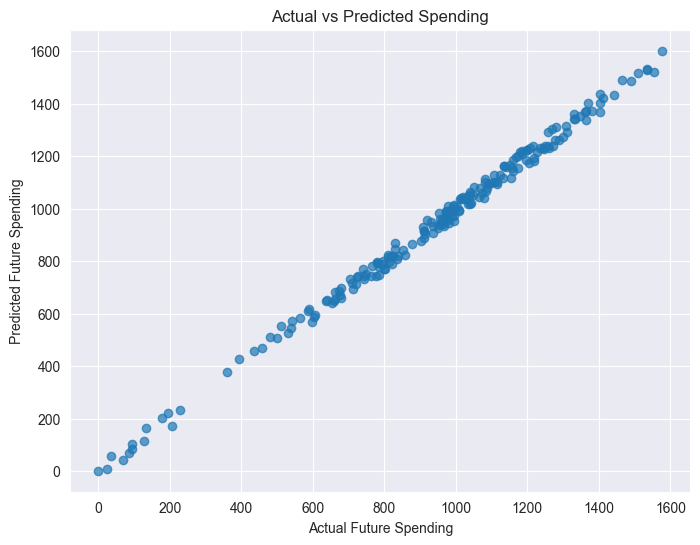

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.xlabel("Actual Future Spending")
plt.ylabel("Predicted Future Spending")

plt.title("Actual vs Predicted Spending")

plt.show()

## Model Export

The final trained Lasso Regression model and the fitted `StandardScaler` object were exported using `joblib` in order to enable future reuse and deployment.

Saving both objects is important because:
- The trained model is required for future predictions
- The scaler ensures that new input data is transformed in the same way as the training data

This allows the prediction pipeline to remain consistent during deployment inside the shopping website backend.

In [17]:
import joblib

joblib.dump(best_model, "user_spending_lasso_model.pkl")
joblib.dump(scaler, "user_spending_scaler.pkl")

print("Final model and scaler exported successfully.")

Final model and scaler exported successfully.


## Example Prediction

The following example demonstrates how the trained model can generate a future spending prediction for a new user based on behavioral features.

The user data is first transformed using the previously fitted scaler and then passed into the trained Lasso Regression model for inference.

In [19]:
example_user = pd.DataFrame([{
    "favorite_count": 5,
    "closed_orders_count": 2,
    "total_items_purchased": 6,
    "average_order_value": 90,
    "days_since_registration": 120
}])

example_user_scaled = scaler.transform(example_user)

prediction = best_model.predict(example_user_scaled)

print("Estimated future spending (NIS):", round(prediction[0], 2))

Estimated future spending (NIS): 417.48
